# Geodesic PCA on SPD matrices that are diagonalizable in the same basis

The Bures Wasserstein distance between two SPD matrices that are diagonalizable in the same orthonormal basis is the Euclidean distance between the vectors of their eigenvalues square roots. In this notebook, we check that PGA on a set of SPD matrices that are diagonalizable in the same basis is equivalent to Euclidean PCA on their eigenvalues square roots. We randomly generate diagonal SPD matrices, perform PGA and plot the results. Each SPD matrix is represented by the image of the unit circle by the linear transformation of the plane induced by the matrix, i.e., an ellipse.

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import pca.bures_wasserstein_principal_geodesic_analysis as pca
from tools.plot_2d import *
from tools.compute import make_rotation_2d

INFO: Using numpy backend


In [3]:
dim = 2
n = 5
e1 = np.linspace(1., np.sqrt(3), n)
e2 = np.linspace(1., np.sqrt(2), n)
ee = np.meshgrid(e1, e2)
eig_sq_roots = np.stack(ee).T.reshape((n ** 2, dim))
points_spd = np.stack([np.diag(eig_sq_roots[i] ** 2) for i in range(n**2)])

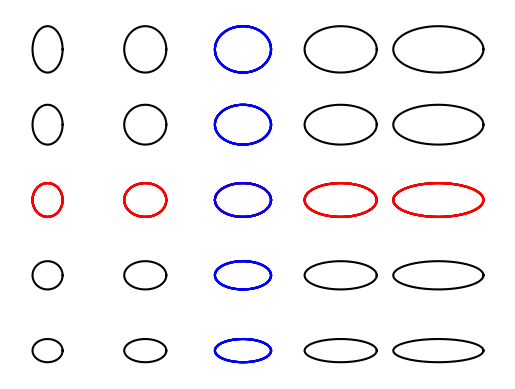

In [4]:
gpca = pca.BuresWassersteinPGA(dim=2).fit(points_spd)

plot_pca_results_with_ellipses_on_grid(points_spd, gpca, n=5)

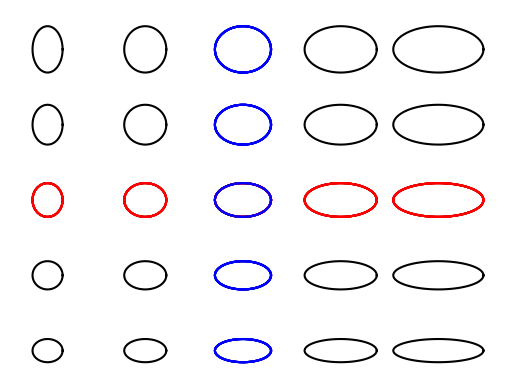

In [5]:
tpca = pca.BuresWassersteinTPCA().fit(points_spd)

plot_pca_results_with_ellipses_on_grid(points_spd, tpca, n=5)

/Users/alebrigant/PycharmProjects/bures_wasserstein_pga/tools/plot_2d.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  angle = np.arctan(- eigenvec[0, 1] / eigenvec[1, 1])


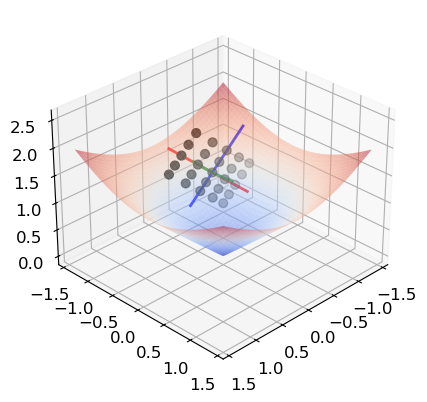

In [6]:
font = {'size': 12}
matplotlib.rc('font', **font)

plot_pca_results_in_cone(points_spd, gpca, bound=1.4)